## Import Library

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

## Dataset

In [5]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

## Exploratory Data Analysis (EDA)

In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB


In [8]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### Check Missing Value

In [10]:
df_train.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [11]:
df_test.isnull().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

### Visualization Train Data

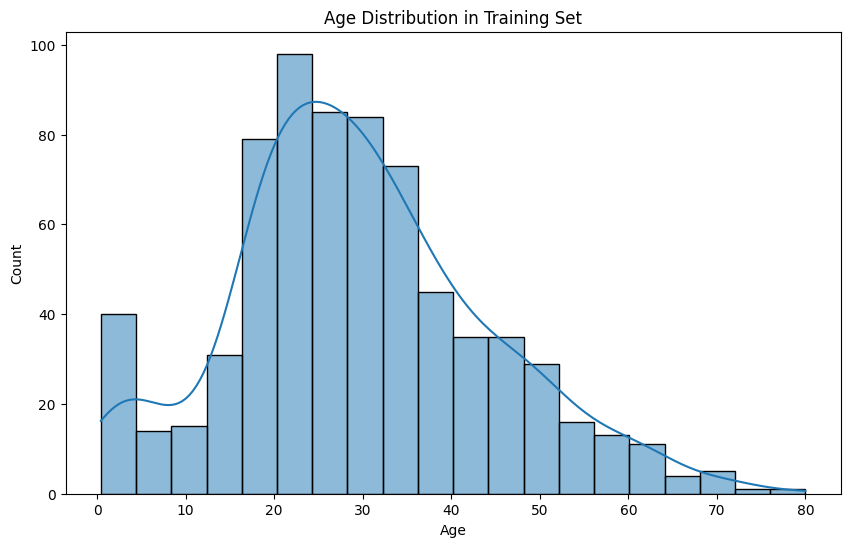

In [12]:
plt.figure(figsize=(10,6))
sns.histplot(df_train['Age'], kde=True)
plt.title('Age Distribution in Training Set')
plt.show()

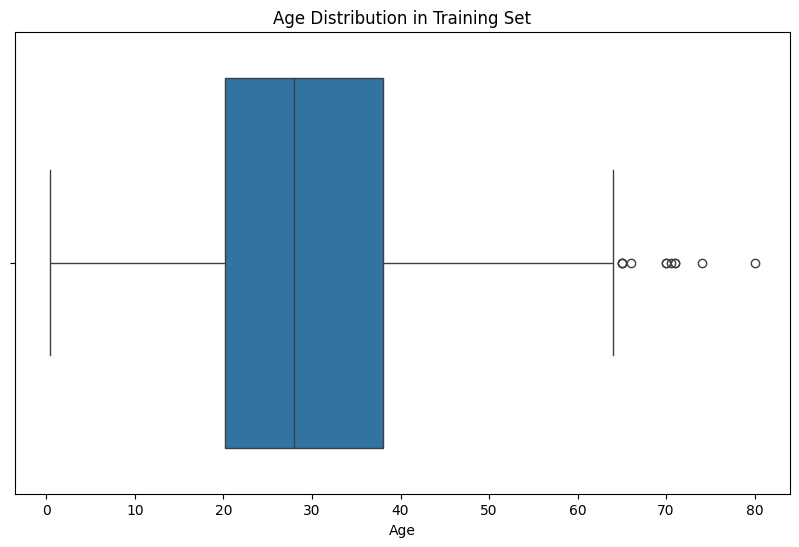

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df_train['Age'])
plt.title('Age Distribution in Training Set')
plt.show()

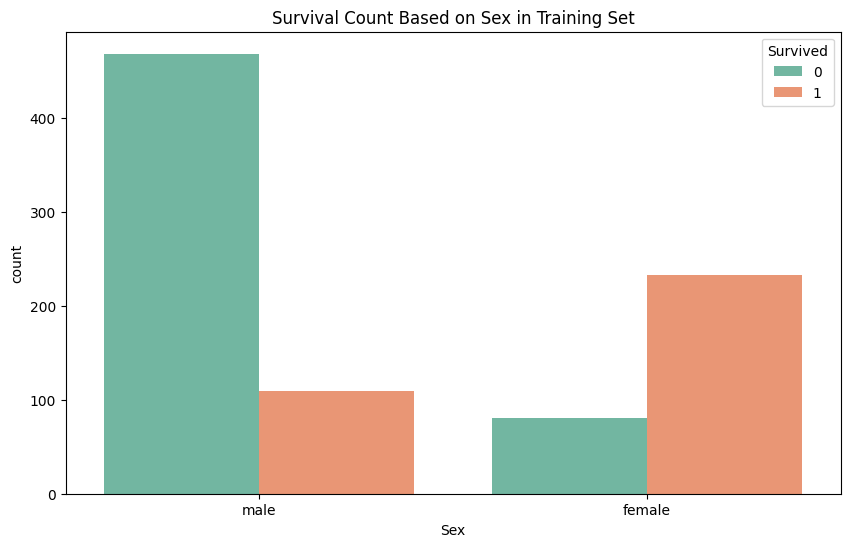

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x=df_train['Sex'], hue=df_train['Survived'], palette='Set2')
plt.title('Survival Count Based on Sex in Training Set')
plt.show()

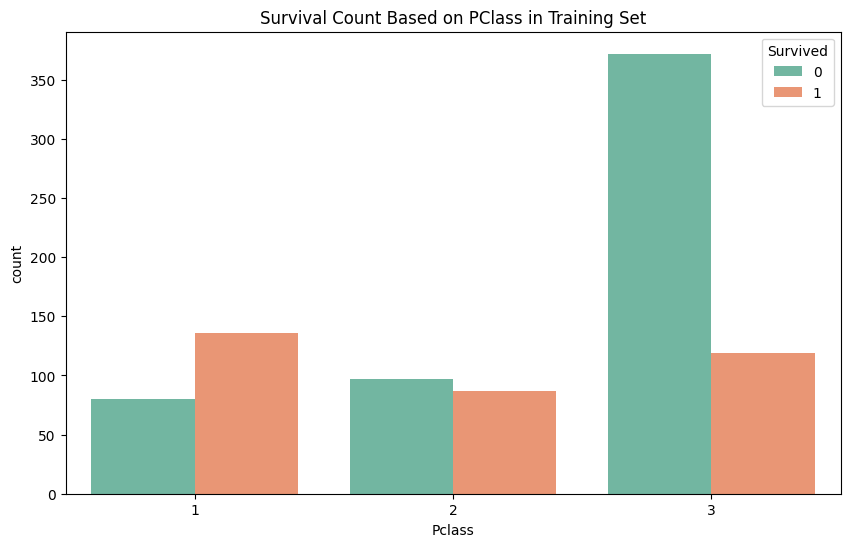

In [15]:
plt.figure(figsize=(10,6))
sns.countplot(x=df_train['Pclass'], hue=df_train['Survived'], palette='Set2')
plt.title('Survival Count Based on PClass in Training Set')
plt.show()

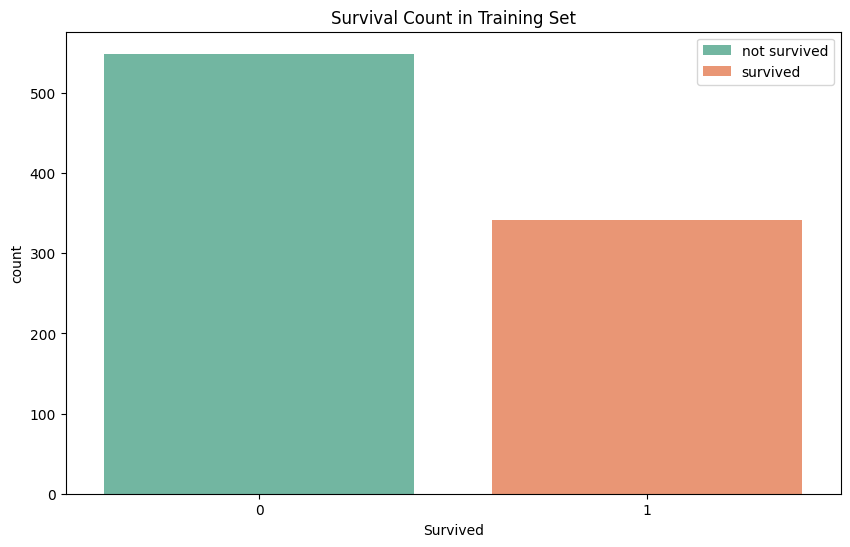

In [38]:
plt.figure(figsize=(10,6))
sns.countplot(x='Survived', hue='Survived', palette='Set2', data=df_train)
plt.title('Survival Count in Training Set')
plt.legend(['not survived', 'survived'], loc='upper right')
plt.show()

### Heatmap Correlation

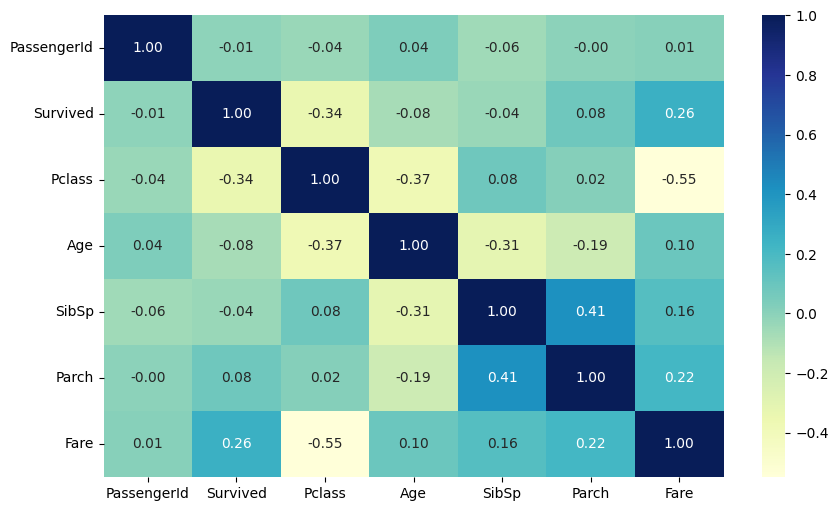

In [17]:
num_df = df_train.select_dtypes(include=[np.number])
corr = num_df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap='YlGnBu', fmt='.2f')
plt.show()

## **Insight**
- The safety level of men tends to be lower than women
- Class 1 has the highest safety level (the higher the class, the higher the safety level)
- PClass and Fare have a high correlation to determine the safety level so that the two features can be used to estimate whether passengers can survive or not
- Correlation of Fare and PClass is the higher the class, the more expensive the price
- The frequency of survivors is smaller than those who do not survive

### Unique Value

In [18]:
print(df_train['Sex'].unique())
print(df_train['Embarked'].unique())
print(df_train['Pclass'].unique())

['male' 'female']
['S' 'C' 'Q' nan]
[3 1 2]


### Check Duplicate

In [19]:
print(df_train.duplicated().sum())
print(df_test.duplicated().sum())

0
0


## Preprocessing

### Drop Irrelevant Column

In [20]:
irrelevant_features = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_train.drop(irrelevant_features, axis=1, inplace=True)
df_test.drop(irrelevant_features, axis=1, inplace=True)

In [21]:
print(df_train.columns)
print(df_test.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'Embarked'],
      dtype='object')
Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')


### Fill Missing Value

In [41]:
df_train['Age'] = df_train['Age'].fillna(df_train['Age'].median())
df_train['Embarked'] = df_train['Embarked'].fillna(df_train['Embarked'].mode()[0])
df_train.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

In [42]:
df_test['Age'] = df_test['Age'].fillna(df_test['Age'].median())
df_test['Embarked'] = df_test['Embarked'].fillna(df_test['Embarked'].mode()[0])
df_test['Fare'] = df_test['Fare'].fillna(df_test['Fare'].median())
df_test.isnull().sum()

Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

### Data Encoding

In [43]:
encode = LabelEncoder()

df_train['Sex'] = encode.fit_transform(df_train['Sex'])
df_train['Embarked'] = encode.fit_transform(df_train['Embarked'])
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


In [44]:
df_test['Sex'] = encode.fit_transform(df_test['Sex'])
df_test['Embarked'] = encode.fit_transform(df_test['Embarked'])
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Pclass    418 non-null    int64  
 1   Sex       418 non-null    int64  
 2   Age       418 non-null    float64
 3   SibSp     418 non-null    int64  
 4   Parch     418 non-null    int64  
 5   Fare      418 non-null    float64
 6   Embarked  418 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 23.0 KB


### Data Normalization

In [46]:
scaler = MinMaxScaler()

df_train[['Age', 'Fare']] = scaler.fit_transform(df_train[['Age', 'Fare']])

In [47]:
df_test[['Age', 'Fare']] = scaler.fit_transform(df_test[['Age', 'Fare']])

## Modelling (Logistic Regression)

### Using Testing Data

In [28]:
x = df_train.drop(columns=['Survived'])
y = df_train['Survived']

test = df_test

In [29]:
model = LogisticRegression(random_state=42)
model.fit(x, y)
y_pred = model.predict(test)

In [30]:
y_pred_proba = model.predict_proba(test)
print(y_pred_proba)

[[0.89940927 0.10059073]
 [0.61178334 0.38821666]
 [0.87800765 0.12199235]
 [0.90005936 0.09994064]
 [0.44522771 0.55477229]
 [0.86004763 0.13995237]
 [0.36487034 0.63512966]
 [0.81337397 0.18662603]
 [0.24334949 0.75665051]
 [0.92887247 0.07112753]
 [0.90012466 0.09987534]
 [0.66687869 0.33312131]
 [0.08578173 0.91421827]
 [0.92393205 0.07606795]
 [0.16223736 0.83776264]
 [0.15199609 0.84800391]
 [0.76467521 0.23532479]
 [0.82731514 0.17268486]
 [0.46673922 0.53326078]
 [0.41539468 0.58460532]
 [0.67951473 0.32048527]
 [0.85053695 0.14946305]
 [0.07711977 0.92288023]
 [0.38566817 0.61433183]
 [0.11238054 0.88761946]
 [0.95886252 0.04113748]
 [0.04522582 0.95477418]
 [0.83351628 0.16648372]
 [0.63252051 0.36747949]
 [0.90818027 0.09181973]
 [0.89238575 0.10761425]
 [0.83589842 0.16410158]
 [0.5397464  0.4602536 ]
 [0.49511153 0.50488847]
 [0.50478288 0.49521712]
 [0.81657547 0.18342453]
 [0.39781563 0.60218437]
 [0.35633465 0.64366535]
 [0.8945773  0.1054227 ]
 [0.89591002 0.10408998]


### Using Training Data

In [31]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

### Evaluation

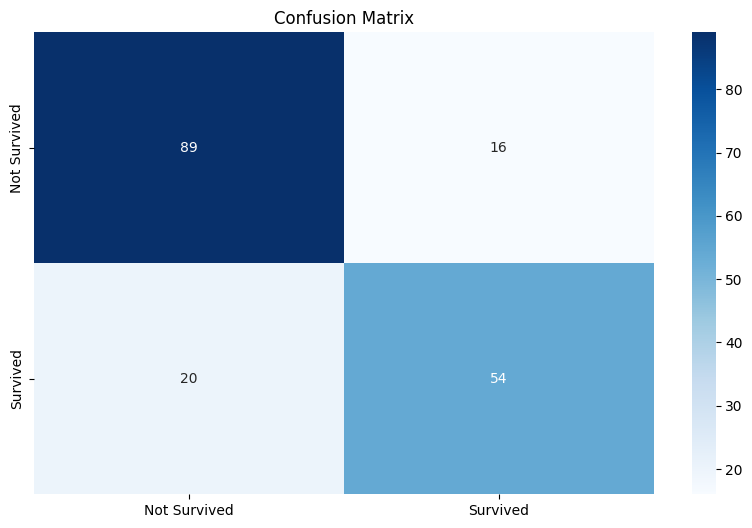

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred))

## Modelling (Naive Bayes)

In [33]:
naive_bayes_model = GaussianNB()

naive_bayes_model.fit(x_train, y_train)
y_pred_nb = naive_bayes_model.predict(x_test)
y_pred_nb_proba = naive_bayes_model.predict_proba(x_test)
print(y_pred_nb_proba)

[[8.22244532e-01 1.77755468e-01]
 [9.24288698e-01 7.57113017e-02]
 [9.57340902e-01 4.26590983e-02]
 [1.09606940e-01 8.90393060e-01]
 [9.34037120e-02 9.06596288e-01]
 [1.82709143e-02 9.81729086e-01]
 [2.90420963e-01 7.09579037e-01]
 [9.88622886e-01 1.13771139e-02]
 [2.45093528e-01 7.54906472e-01]
 [6.23643212e-02 9.37635679e-01]
 [6.91127073e-01 3.08872927e-01]
 [9.59946726e-01 4.00532741e-02]
 [9.68178020e-01 3.18219803e-02]
 [8.34213491e-01 1.65786509e-01]
 [9.24879522e-01 7.51204782e-02]
 [4.40984744e-02 9.55901526e-01]
 [6.83970624e-01 3.16029376e-01]
 [2.90518010e-01 7.09481990e-01]
 [9.22636483e-01 7.73635172e-02]
 [6.48415845e-01 3.51584155e-01]
 [9.60378385e-01 3.96216151e-02]
 [7.71240521e-01 2.28759479e-01]
 [3.74683884e-01 6.25316116e-01]
 [9.57624094e-01 4.23759058e-02]
 [9.63060688e-01 3.69393122e-02]
 [9.98838879e-01 1.16112100e-03]
 [3.86401902e-01 6.13598098e-01]
 [9.24802866e-01 7.51971340e-02]
 [9.98486891e-01 1.51310893e-03]
 [3.95201295e-01 6.04798705e-01]
 [9.563657

### Evaluation

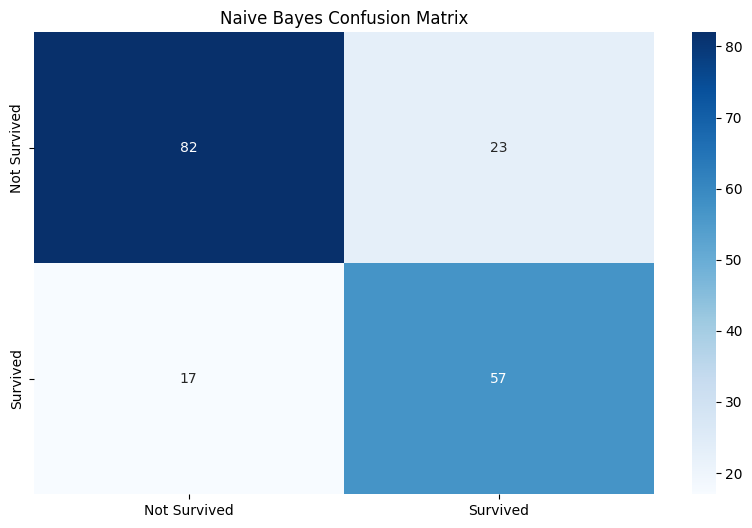

              precision    recall  f1-score   support

           0       0.83      0.78      0.80       105
           1       0.71      0.77      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179



In [34]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(10,6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.title('Naive Bayes Confusion Matrix')
plt.show()

print(classification_report(y_test, y_pred_nb))

## Conclusion
- Logistic Regression with an accuracy of 0.80 is better than Naive Bayes with an accuracy of 0.78
- This is because the features in the titanic dataset have a high correlation so that it is not suitable when used with Naive Bayes where Naive Bayes assumes that all features have no correlation at all (independent)
- However, the difference in performance may not be significant in some cases. The selection of the best model depends on the characteristics of the data and the specific purpose of the analysis. It should also be noted that the results may differ with different datasets or data processing.